**Re-executed 2026-07-25 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0.** Fix applied: this notebook was written 2026-06-28 against the Sobol active-set estimator of git commit `64abb2d` ("antithetic", best submission #313687 era) — its Section-8 decomposition reads module constants (`_BLOCK_CLASS_START_LAYER`, `_NLN_*`, `_COV_*`, ...) that no longer exist in today's `estimator.py` (= submission 318873 bytes). The setup cell therefore now extracts and analyzes the **preserved `64abb2d:estimator.py` bytes** (via `git show`, cached at `.tmp/estimator_64abb2d_snapshot.py`) instead of the repo-root `estimator.py`, so all diagnostics below refer to that older algorithm, matching the recorded narrative. Net sample: nets 0–7 of aicrowd/arc-whestbench-public-2026, v1-phase1, mini split (single-net sections use the worst-final-MSE net among them).

*Divergence note (2026-07-25): re-run numbers shifted slightly vs the recorded 2026-06-28 run (mean final-layer MSE over nets 0-7: 3.15e-06 -> 3.25e-06; diagnostic net 2 cole-martin: 1.26e-05 -> 1.35e-05; pilot-component errors are bit-identical, main/combined moved ~3-8% and the six worst units are the same set in slightly different order). Attributable to numpy/flopscope backend drift in the main sampling path, not an algorithm change; all recorded conclusions (combined < main << pilot/fallback, error concentrated in large-magnitude always-on units) are unchanged.*

# Estimator Diagnostics

This notebook compares `estimator.py` predictions against the baked WHest public mini ground truth for a small set of MLPs. It is designed to answer where the estimator is failing: which layers, which neurons, and whether errors concentrate in dead/rare/core units.

## 1. Setup

Adjust `EVAL_MLP_INDICES` to inspect different public-mini MLPs. The default keeps the run small enough for interactive diagnosis.

In [1]:
from __future__ import annotations

import importlib.util
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import whestbench as wb

# Load the preserved 2026-06-28 estimator bytes this notebook analyzes (git 64abb2d),
# NOT the repo-root estimator.py (which now holds the submission-318873 algorithm).
REPO_DIR = Path("/Users/natashastewart/whest-kprop-experiments")
SNAPSHOT_REF = "64abb2d"
_snap_path = REPO_DIR / ".tmp" / f"estimator_{SNAPSHOT_REF}_snapshot.py"
_snap_path.parent.mkdir(exist_ok=True)
_snap_path.write_bytes(
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "show", f"{SNAPSHOT_REF}:estimator.py"],
        check=True, capture_output=True,
    ).stdout
)
_spec = importlib.util.spec_from_file_location(f"estimator_{SNAPSHOT_REF}", _snap_path)
estimator_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(estimator_module)
print(f"Analyzing estimator bytes: git {SNAPSHOT_REF}:estimator.py -> {_snap_path.name}")

plt.rcParams.update({
    "figure.dpi": 125,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REPO = "aicrowd/arc-whestbench-public-2026"
REVISION = "v1-phase1"
SPLIT = "mini"
BUDGET = 272_000_000_000
EVAL_MLP_INDICES = list(range(8))  # nets 0-7 of the mini split
DATASET_LABEL = f"{REPO}, {REVISION}, {SPLIT} split"

Estimator = estimator_module.Estimator

ds = wb.load_dataset(REPO, revision=REVISION, split=SPLIT)
print(f"Loaded {len(ds)} MLPs from hf://{REPO}@{REVISION} [{SPLIT}]")

Analyzing estimator bytes: git 64abb2d:estimator.py -> estimator_64abb2d_snapshot.py


whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded 100 MLPs from hf://aicrowd/arc-whestbench-public-2026@v1-phase1 [mini]


## 2. Run Predictions

This cell computes `estimator.py` predictions and aligns them with the baked `all_layer_means` ground truth. The resulting arrays have shape `(n_mlp, depth, width)`.

In [2]:
pred_rows = []
truth_rows = []
mlp_names = []

for mlp_idx in EVAL_MLP_INDICES:
    mlp = wb.mlp_at(ds, mlp_idx)
    pred = np.asarray(Estimator().predict(mlp, BUDGET), dtype=np.float64)
    truth = np.asarray(ds[mlp_idx]["all_layer_means"], dtype=np.float64)

    pred_rows.append(pred)
    truth_rows.append(truth)
    mlp_names.append(ds[mlp_idx].get("mlp_name", f"mlp-{mlp_idx}"))

pred = np.stack(pred_rows, axis=0)
truth = np.stack(truth_rows, axis=0)
err = pred - truth
sqerr = err * err
layer_mse = sqerr.mean(axis=2)
final_abs_err = np.abs(err[:, -1, :])

print(f"pred shape:  {pred.shape}")
print(f"truth shape: {truth.shape}")
print(f"all-layer MSE:  {sqerr.mean():.6e}")
print(f"final-layer MSE: {layer_mse[:, -1].mean():.6e}")
print()
print("idx  name                         all_mse      final_mse    worst_final_abs_err")
for row_pos, mlp_idx in enumerate(EVAL_MLP_INDICES):
    print(
        f"{mlp_idx:>3}  {mlp_names[row_pos][:26]:<26}  "
        f"{sqerr[row_pos].mean():>10.3e}  "
        f"{layer_mse[row_pos, -1]:>10.3e}  "
        f"{final_abs_err[row_pos].max():>10.3e}"
    )

pred shape:  (8, 32, 256)
truth shape: (8, 32, 256)
all-layer MSE:  7.400375e-06
final-layer MSE: 3.247573e-06

idx  name                         all_mse      final_mse    worst_final_abs_err
  0  daniel-harrison              6.535e-06   2.193e-06   5.690e-03
  1  dustin-robinson              1.049e-05   6.427e-06   9.502e-03
  2  cole-martin                  1.195e-05   1.354e-05   1.425e-02
  3  donna-clarke                 6.062e-06   6.049e-07   2.875e-03
  4  rebecca-walker               5.643e-06   5.157e-07   2.650e-03
  5  monique-stevens              6.634e-06   1.614e-06   5.269e-03
  6  keith-brock                  6.439e-06   5.312e-07   3.105e-03
  7  robert-huff                  5.454e-06   5.577e-07   3.686e-03


## 3. Layer-Level Error

The line plot shows where error accumulates with depth. The heatmap shows whether failures are MLP-specific or systematic across layers.

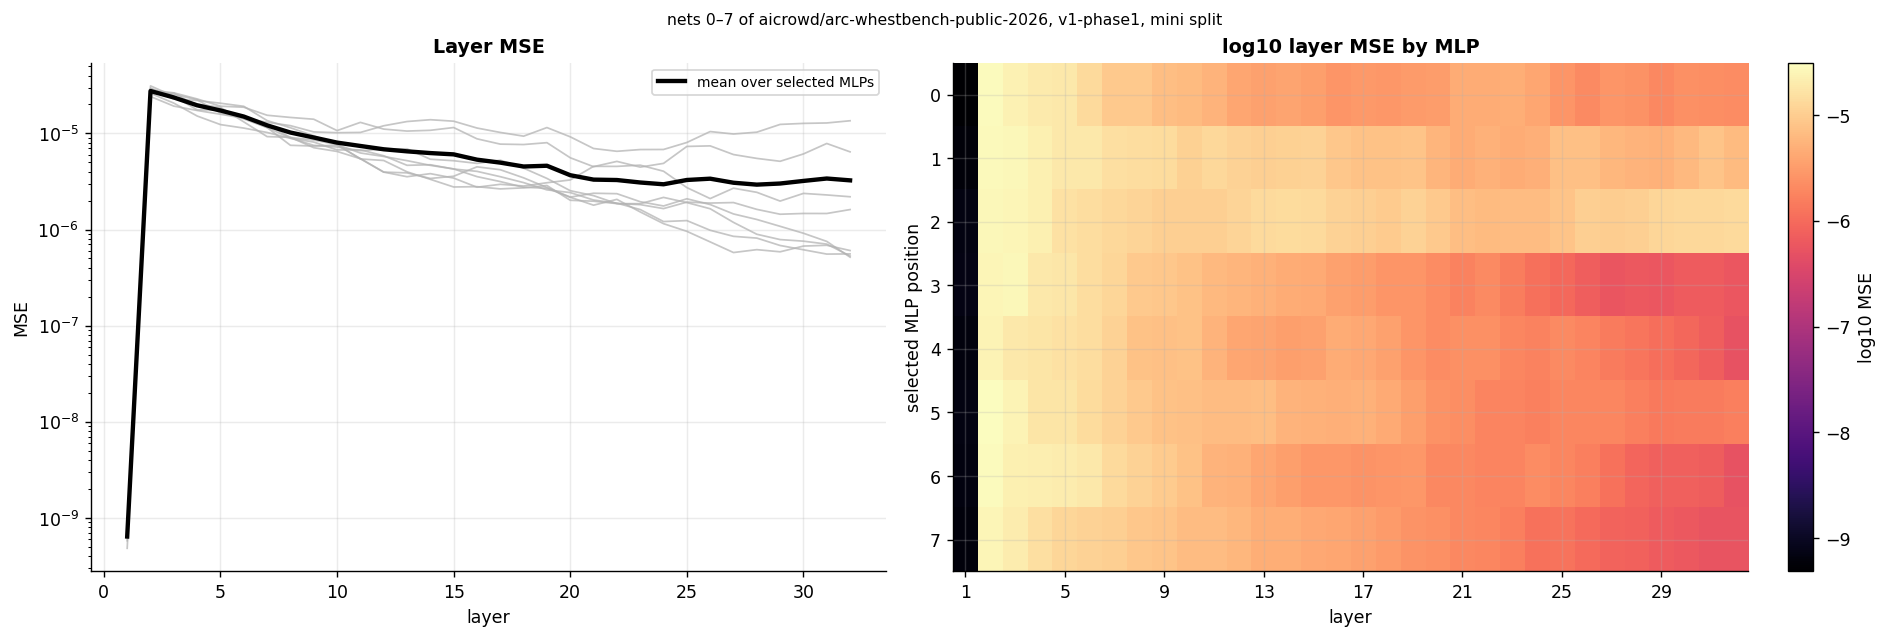

In [3]:
layers = np.arange(1, pred.shape[1] + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
fig.suptitle(f"nets {EVAL_MLP_INDICES[0]}\u2013{EVAL_MLP_INDICES[-1]} of {DATASET_LABEL}", fontsize=9)

for row_pos, mlp_idx in enumerate(EVAL_MLP_INDICES):
    axes[0].plot(layers, layer_mse[row_pos], color="0.7", lw=1, alpha=0.75)
axes[0].plot(layers, layer_mse.mean(axis=0), color="black", lw=2.5, label="mean over selected MLPs")
axes[0].set_yscale("log")
axes[0].set(title="Layer MSE", xlabel="layer", ylabel="MSE")
axes[0].legend()

heat = np.log10(np.maximum(layer_mse, 1e-12))
im = axes[1].imshow(heat, aspect="auto", cmap="magma")
axes[1].set(
    title="log10 layer MSE by MLP",
    xlabel="layer",
    ylabel="selected MLP position",
    xticks=np.arange(0, pred.shape[1], 4),
    xticklabels=np.arange(1, pred.shape[1] + 1, 4),
    yticks=np.arange(len(EVAL_MLP_INDICES)),
    yticklabels=EVAL_MLP_INDICES,
)
fig.colorbar(im, ax=axes[1], label="log10 MSE")
plt.show()

## 4. Per-MLP Heatmaps

Choose one MLP position from the evaluated list. The error heatmap highlights layer/unit regions where the prediction is biased high or low.

diagnostic MLP index: 2 (cole-martin)
final-layer MSE: 1.353778e-05


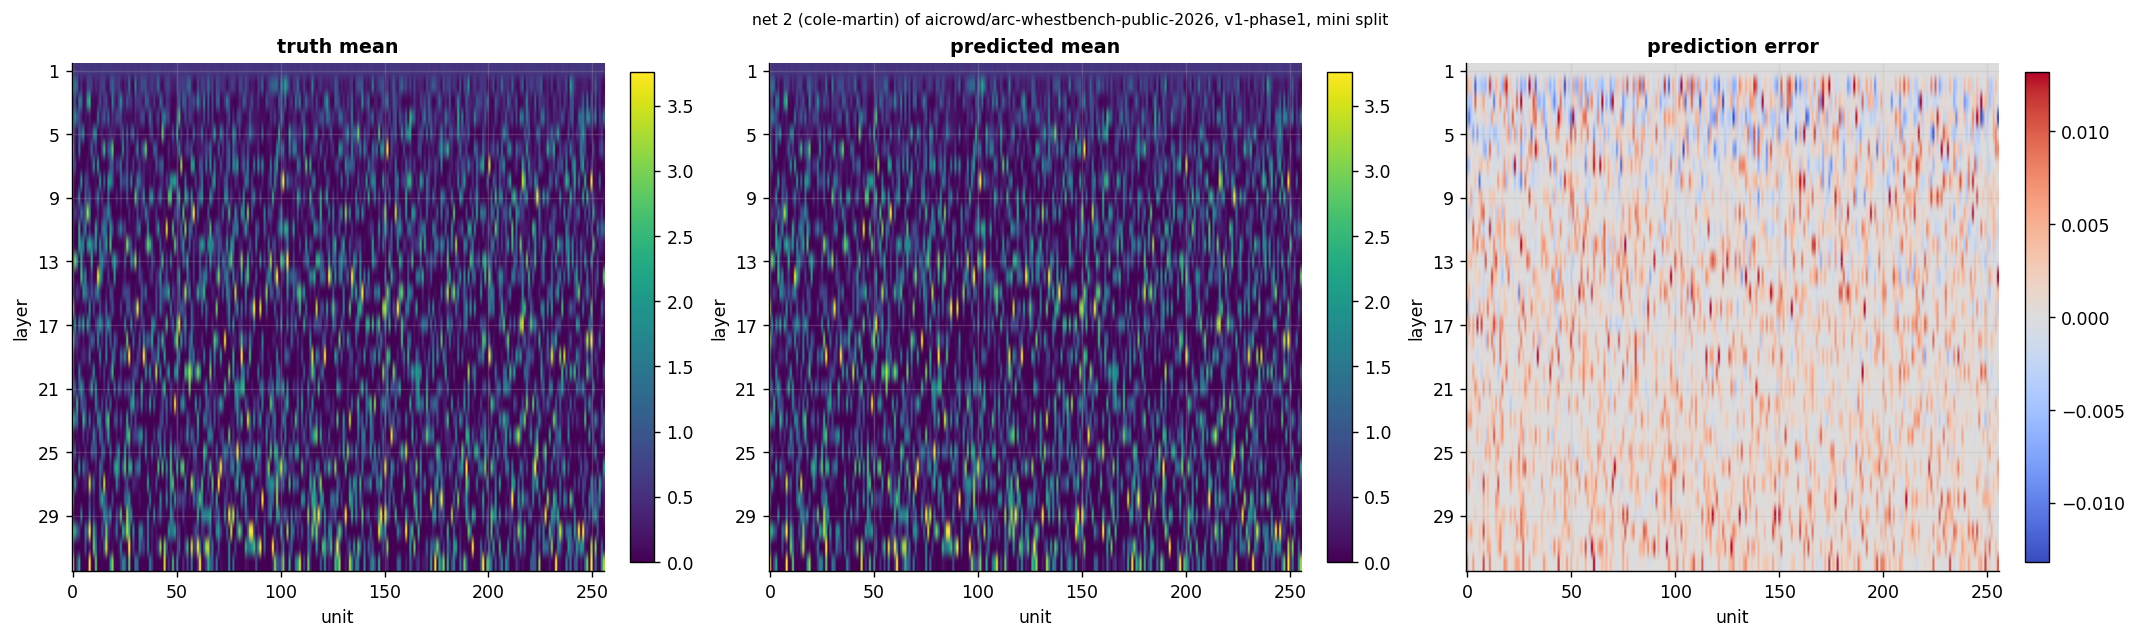

In [4]:
DIAG_MLP_POSITION = int(np.argmax(layer_mse[:, -1]))
print(f"diagnostic MLP index: {EVAL_MLP_INDICES[DIAG_MLP_POSITION]} ({mlp_names[DIAG_MLP_POSITION]})")
print(f"final-layer MSE: {layer_mse[DIAG_MLP_POSITION, -1]:.6e}")

truth_one = truth[DIAG_MLP_POSITION]
pred_one = pred[DIAG_MLP_POSITION]
err_one = err[DIAG_MLP_POSITION]
DIAG_NET_LABEL = (f"net {EVAL_MLP_INDICES[DIAG_MLP_POSITION]} ({mlp_names[DIAG_MLP_POSITION]}) "
                  f"of {DATASET_LABEL}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)

truth_vmax = np.quantile(truth_one, 0.995)
for ax, data, title in [
    (axes[0], truth_one, "truth mean"),
    (axes[1], pred_one, "predicted mean"),
]:
    im = ax.imshow(data, aspect="auto", cmap="viridis", vmin=0, vmax=truth_vmax)
    ax.set(title=title, xlabel="unit", ylabel="layer")
    ax.set_yticks(np.arange(0, pred.shape[1], 4), labels=np.arange(1, pred.shape[1] + 1, 4))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

err_lim = np.quantile(np.abs(err_one), 0.995)
im = axes[2].imshow(err_one, aspect="auto", cmap="coolwarm", vmin=-err_lim, vmax=err_lim)
axes[2].set(title="prediction error", xlabel="unit", ylabel="layer")
axes[2].set_yticks(np.arange(0, pred.shape[1], 4), labels=np.arange(1, pred.shape[1] + 1, 4))
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

## 5. Worst Final-Layer Neuron Trajectories

This follows final-layer units with the largest absolute final error backward through their same unit index across layers. It is not a path attribution, but it quickly shows whether the error is born late or accumulates through depth.

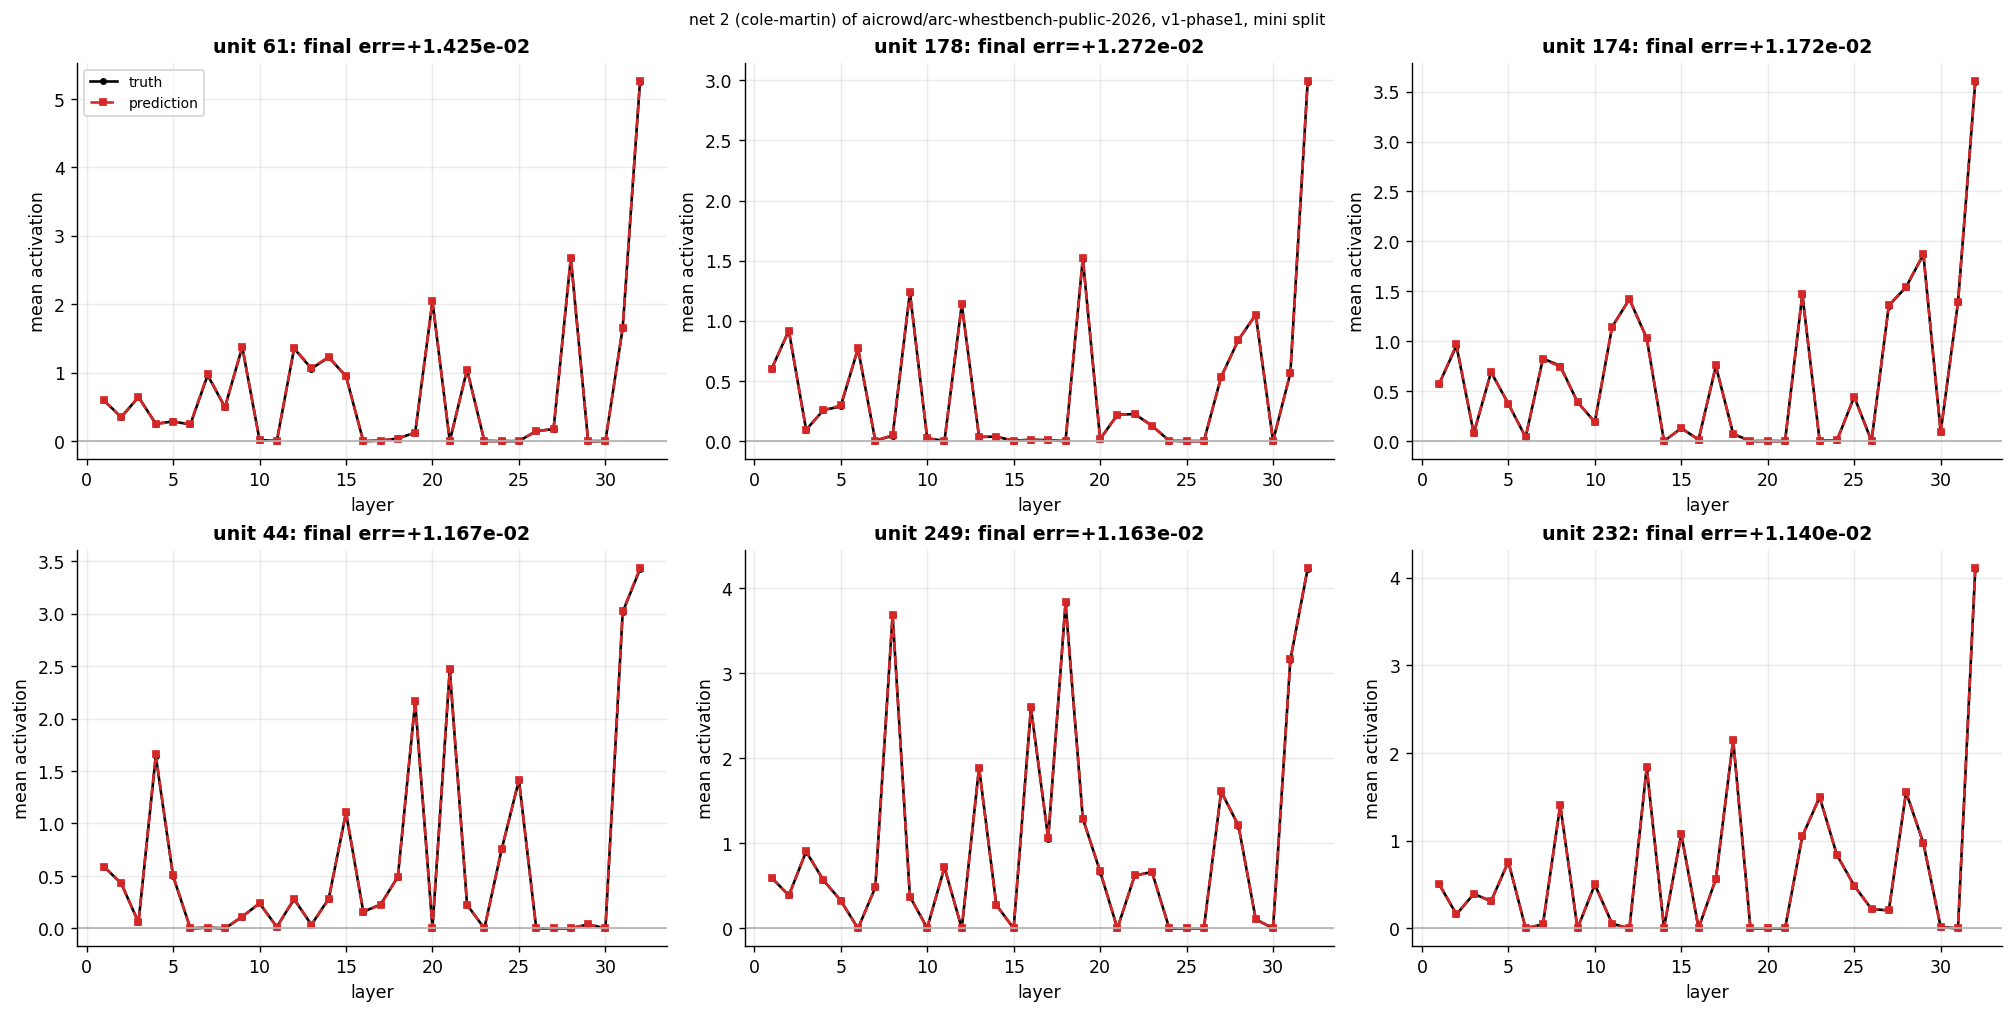

worst final-layer units
unit  truth_final  pred_final   signed_err   abs_err
  61   5.2536e+00  5.2678e+00  +1.4248e-02  1.4248e-02
 178   2.9835e+00  2.9962e+00  +1.2718e-02  1.2718e-02
 174   3.5970e+00  3.6087e+00  +1.1719e-02  1.1719e-02
  44   3.4225e+00  3.4341e+00  +1.1667e-02  1.1667e-02
 249   4.2284e+00  4.2400e+00  +1.1632e-02  1.1632e-02
 232   4.0976e+00  4.1090e+00  +1.1404e-02  1.1404e-02


In [5]:
TOP_K_UNITS = 6
worst_units = np.argsort(np.abs(err_one[-1]))[-TOP_K_UNITS:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)
for ax, unit_idx in zip(axes.ravel(), worst_units):
    ax.plot(layers, truth_one[:, unit_idx], "o-", color="black", ms=3, label="truth")
    ax.plot(layers, pred_one[:, unit_idx], "s--", color="#d62728", ms=3, label="prediction")
    ax.axhline(0, color="0.7", lw=1)
    ax.set(
        title=f"unit {unit_idx}: final err={err_one[-1, unit_idx]:+.3e}",
        xlabel="layer",
        ylabel="mean activation",
    )
axes[0, 0].legend()
plt.show()

print("worst final-layer units")
print("unit  truth_final  pred_final   signed_err   abs_err")
for unit_idx in worst_units:
    print(
        f"{unit_idx:>4}  "
        f"{truth_one[-1, unit_idx]:>11.4e}  "
        f"{pred_one[-1, unit_idx]:>10.4e}  "
        f"{err_one[-1, unit_idx]:>+10.4e}  "
        f"{abs(err_one[-1, unit_idx]):>9.4e}"
    )

## 6. Predicted vs True Scatter by Layer

These scatter plots separate broad calibration failures from a small number of bad neurons. Points far above or below the diagonal are units where the estimator is systematically biased.

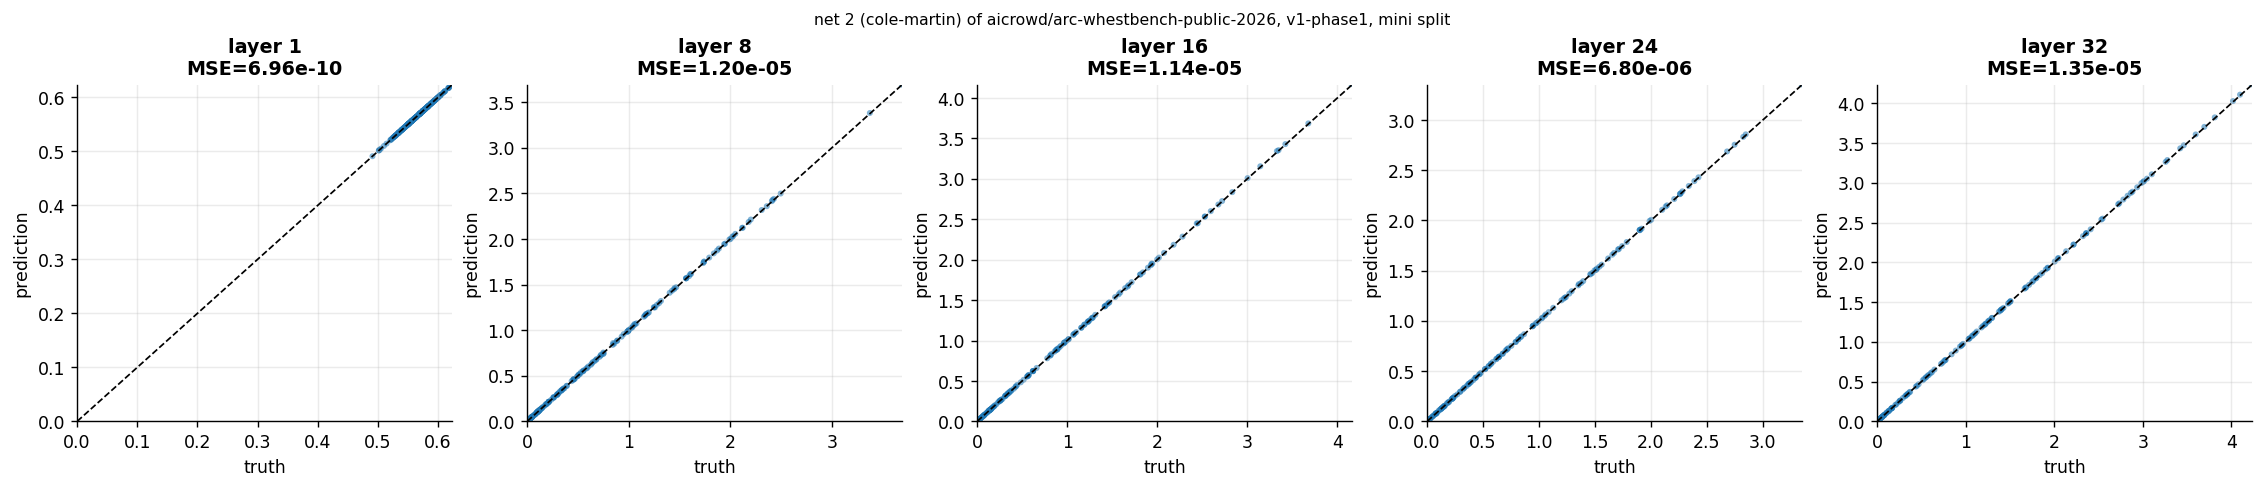

In [6]:
SCATTER_LAYERS = [0, 7, 15, 23, 31]
fig, axes = plt.subplots(1, len(SCATTER_LAYERS), figsize=(18, 3.8), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)

for ax, layer_idx in zip(axes, SCATTER_LAYERS):
    t = truth_one[layer_idx]
    p = pred_one[layer_idx]
    layer_lim = np.quantile(np.concatenate([t, p]), 0.995)
    ax.scatter(t, p, s=12, alpha=0.55, color="#1f77b4", edgecolor="none")
    ax.plot([0, layer_lim], [0, layer_lim], "--", color="black", lw=1)
    ax.set(
        title=f"layer {layer_idx + 1}\nMSE={np.mean((p - t)**2):.2e}",
        xlabel="truth",
        ylabel="prediction",
        xlim=(0, layer_lim),
        ylim=(0, layer_lim),
    )
plt.show()

## 7. Error vs Activation Magnitude

This plot checks whether final-layer failures are concentrated in small, near-dead units or in large-magnitude active/core units.

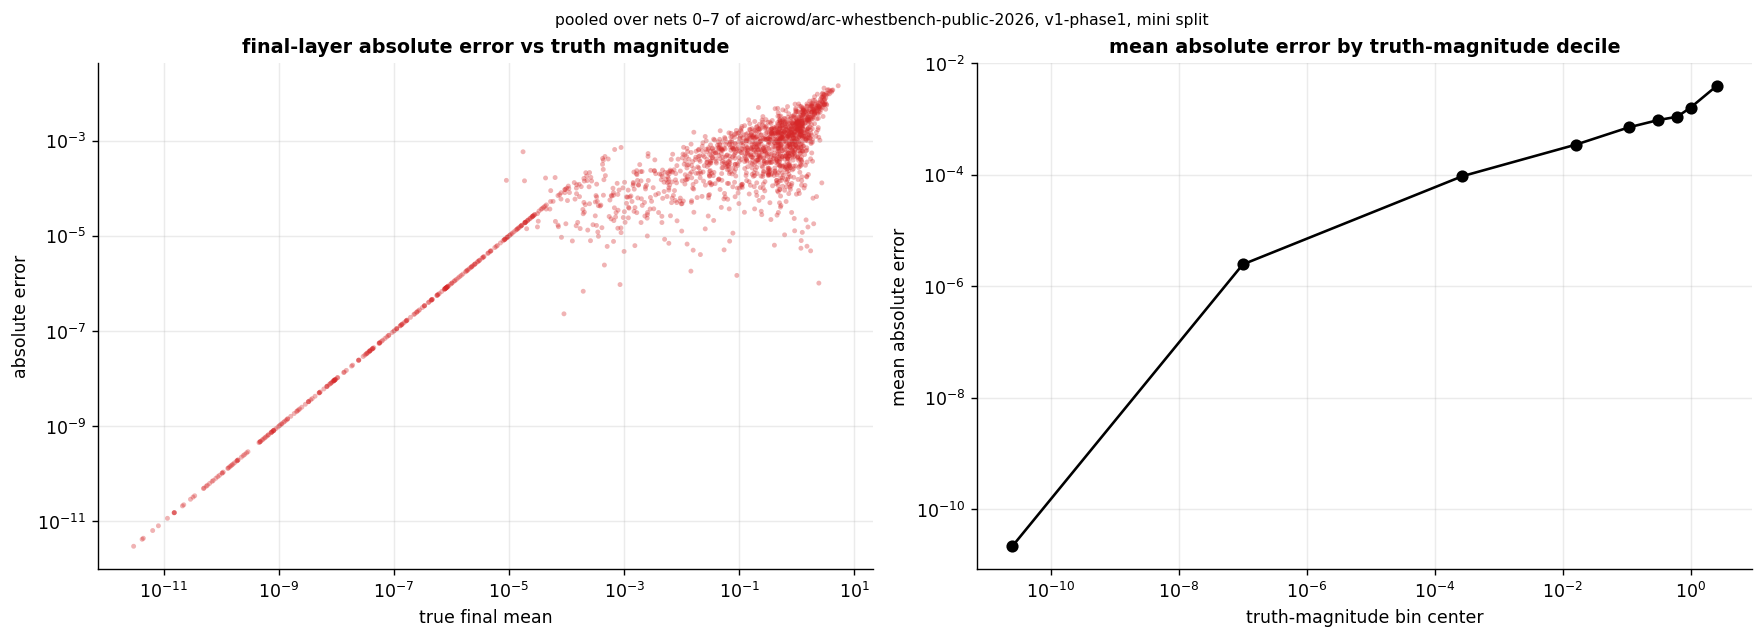

In [7]:
final_truth = truth[:, -1, :].ravel()
final_pred = pred[:, -1, :].ravel()
final_error = final_pred - final_truth
final_abs_error = np.abs(final_error)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle(f"pooled over nets {EVAL_MLP_INDICES[0]}\u2013{EVAL_MLP_INDICES[-1]} of {DATASET_LABEL}", fontsize=9)

axes[0].scatter(final_truth, final_abs_error, s=8, alpha=0.35, color="#d62728", edgecolor="none")
axes[0].set(
    title="final-layer absolute error vs truth magnitude",
    xlabel="true final mean",
    ylabel="absolute error",
    xscale="log",
    yscale="log",
)

bins = np.quantile(final_truth, np.linspace(0, 1, 11))
bins = np.unique(bins)
bin_centers = []
bin_mean_abs_err = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (final_truth >= lo) & (final_truth <= hi)
    if mask.any():
        bin_centers.append(np.sqrt(max(lo, 1e-12) * max(hi, 1e-12)))
        bin_mean_abs_err.append(final_abs_error[mask].mean())
axes[1].plot(bin_centers, bin_mean_abs_err, "o-", color="black")
axes[1].set(
    title="mean absolute error by truth-magnitude decile",
    xlabel="truth-magnitude bin center",
    ylabel="mean absolute error",
    xscale="log",
    yscale="log",
)
plt.show()

## 8. Pilot Information Retention

This section decomposes the estimator into four row-level estimates for one MLP:

- `pilot`: the full-network pilot mean;
- `fallback`: the returned value for inactive units, including lognormal positive-slab shrinkage;
- `main`: the active-subnetwork main estimate before pilot reuse;
- `combined`: the estimate after the current pilot/main sample-count blend.

If `pilot` is much closer to truth than `main` in later layers, then the estimator is discarding useful full-network pilot information.

In [8]:
def _diag_actual_sample_count(n_samples):
    return 2 * max(1, (n_samples + 1) // 2) if estimator_module._USE_ANTITHETIC else n_samples


def _diag_layer_fire_threshold(layer_idx, depth):
    if depth <= 1:
        return estimator_module._FIRE_THRESHOLD
    depth_fraction = layer_idx / float(depth - 1)
    return estimator_module._FIRE_THRESHOLD * (
        1.0 + estimator_module._FIRE_THRESHOLD_GROWTH * depth_fraction * depth_fraction
    )


def _diag_first_layer_activations(rng, n_samples, W):
    width = W.shape[0]
    if estimator_module._USE_ANTITHETIC:
        n_pairs = max(1, (n_samples + 1) // 2)
        half = rng.standard_normal((n_pairs, width)).astype(np.float32)
        z = half @ W
        return np.concatenate([np.maximum(z, 0.0), np.maximum(-z, 0.0)], axis=0)
    x = rng.standard_normal((n_samples, width)).astype(np.float32)
    return np.maximum(x @ W, 0.0)


def _diag_first_layer_relu_mean(W):
    return np.sqrt(np.maximum(np.sum(W * W, axis=0), 1e-30)) * estimator_module._INV_SQRT_TWO_PI


def _diag_positive_slab_stats(x, pilot_mean):
    positive = x > 0.0
    positive_count = positive.sum(axis=0).astype(np.float64)
    sample_count = float(x.shape[0])

    log_x = np.where(positive, np.log(np.maximum(x, 1e-30)), 0.0)
    count_for_logs = np.maximum(positive_count, 1.0)
    log_mean = log_x.sum(axis=0) / count_for_logs
    log_centered = np.where(positive, log_x - log_mean, 0.0)
    log_var = (log_centered * log_centered).sum(axis=0) / np.maximum(positive_count - 1.0, 1.0)
    log_var = np.minimum(log_var, estimator_module._NLN_LOGVAR_CAP)

    firing_rate = (positive_count + 0.5) / (sample_count + 1.0)
    nln_mean = firing_rate * np.exp(log_mean + 0.5 * log_var)
    reliability = np.minimum(1.0, positive_count / estimator_module._NLN_MIN_POSITIVES)
    fallback_mean = pilot_mean + estimator_module._NLN_FALLBACK_BLEND * reliability * (nln_mean - pilot_mean)

    layer_scale = max(float(pilot_mean.mean()), 1e-12)
    nln_keep = (positive_count >= estimator_module._NLN_MIN_POSITIVES) & (
        nln_mean >= estimator_module._NLN_KEEP_FRACTION * layer_scale
    )
    return fallback_mean, nln_keep, firing_rate


def _diag_positive_covariance_degree(x, pilot_mean):
    centered = x - pilot_mean
    cov = centered.T @ centered / max(1, x.shape[0] - 1)
    cov = 0.5 * (cov + cov.T)
    var = np.maximum(np.diag(cov), 1e-12)
    corr = cov / np.sqrt(np.outer(var, var))
    corr = 0.5 * (corr + corr.T)
    support = corr >= estimator_module._COV_CORR_THRESHOLD
    return support.sum(axis=0).astype(np.float64) - 1.0


def _diag_replace_indices(base, idx, values):
    row = np.array(base, copy=True)
    row[idx] = values
    return row


def decompose_estimator_for_mlp(mlp):
    rng = np.random.default_rng(mlp.seed)
    weights = [np.asarray(W, dtype=np.float32) for W in mlp.weights]
    depth = len(weights)
    width = weights[0].shape[0]
    pilot_count = float(_diag_actual_sample_count(estimator_module._PILOT_SAMPLES))
    main_samples = max(1, estimator_module._MAIN_SAMPLES - estimator_module._IMPORTANCE_SAMPLES)
    main_count = float(_diag_actual_sample_count(main_samples))

    x = None
    fallback_rows = []
    pilot_rows = []
    active_indices = []
    active_counts = []
    cov_degree_rows = []
    firing_rows = []

    for layer_idx, W in enumerate(weights):
        if layer_idx == 0:
            x = _diag_first_layer_activations(rng, estimator_module._PILOT_SAMPLES, W)
            exact_mean = _diag_first_layer_relu_mean(W)
            idx = np.arange(width)
            fallback_rows.append(exact_mean)
            pilot_rows.append(exact_mean)
            active_indices.append(idx)
            active_counts.append(width)
            cov_degree_rows.append(np.ones(width) * estimator_module._COV_CORE_DEGREE)
            firing_rows.append(np.ones(width) * 0.5)
            continue

        x = np.maximum(x @ W, 0.0)
        pilot_mean = x.mean(axis=0)
        firing_rate = (x > 0.0).mean(axis=0)

        if layer_idx + 1 < estimator_module._BLOCK_CLASS_START_LAYER:
            idx = np.arange(width)
            fallback_rows.append(pilot_mean)
            pilot_rows.append(pilot_mean)
            active_indices.append(idx)
            active_counts.append(width)
            cov_degree_rows.append(np.ones(width) * estimator_module._COV_CORE_DEGREE)
            firing_rows.append(firing_rate)
            continue

        fallback_mean, nln_keep, _ = _diag_positive_slab_stats(x, pilot_mean)
        keep = (firing_rate >= _diag_layer_fire_threshold(layer_idx, depth)) | nln_keep
        cov_degree = np.zeros(width)
        if estimator_module._USE_SPARSE_COV:
            cov_degree = _diag_positive_covariance_degree(x, pilot_mean)
            keep = keep | (cov_degree >= estimator_module._COV_MIN_DEGREE)
        idx = np.nonzero(keep)[0]

        fallback_rows.append(fallback_mean)
        pilot_rows.append(pilot_mean)
        active_indices.append(idx)
        active_counts.append(int(keep.sum()))
        cov_degree_rows.append(cov_degree)
        firing_rows.append(firing_rate)

    x_main = None
    main_rows = []
    combined_rows = []
    prev_idx = None
    for layer_idx, W in enumerate(weights):
        idx = active_indices[layer_idx]
        active_count = active_counts[layer_idx]

        if layer_idx == 0:
            x_main = _diag_first_layer_activations(rng, main_samples, W)
            main_rows.append(fallback_rows[layer_idx])
            combined_rows.append(fallback_rows[layer_idx])
            prev_idx = idx
            continue

        if active_count == 0:
            main_rows.append(fallback_rows[layer_idx])
            combined_rows.append(fallback_rows[layer_idx])
            x_main = np.zeros((x_main.shape[0], 0), dtype=np.float32)
            prev_idx = idx
            continue

        W_active = W[np.ix_(prev_idx, idx)]
        x_main = np.maximum(x_main @ W_active, 0.0)
        active_mean = x_main.mean(axis=0)
        main_row = _diag_replace_indices(fallback_rows[layer_idx], idx, active_mean)

        if estimator_module._REUSE_PILOT_SAMPLES:
            combined_active = (
                active_mean * main_count + pilot_rows[layer_idx][idx] * pilot_count
            ) / (main_count + pilot_count)
        else:
            combined_active = active_mean
        combined_row = _diag_replace_indices(fallback_rows[layer_idx], idx, combined_active)

        main_rows.append(main_row)
        combined_rows.append(combined_row)
        prev_idx = idx

    return {
        "fallback": np.stack(fallback_rows),
        "pilot": np.stack(pilot_rows),
        "main": np.stack(main_rows),
        "combined": np.stack(combined_rows),
        "active_counts": np.asarray(active_counts),
        "cov_degree": np.stack(cov_degree_rows),
        "firing_rate": np.stack(firing_rows),
        "pilot_count": pilot_count,
        "main_count": main_count,
    }


mlp_idx = EVAL_MLP_INDICES[DIAG_MLP_POSITION]
components = decompose_estimator_for_mlp(wb.mlp_at(ds, mlp_idx))
component_names = ["pilot", "fallback", "main", "combined"]
component_mse = {name: ((components[name] - truth_one) ** 2).mean(axis=1) for name in component_names}

print(f"MLP {mlp_idx}: {mlp_names[DIAG_MLP_POSITION]}")
print(f"pilot_count={components['pilot_count']:.0f}, main_count={components['main_count']:.0f}")
print(f"current pilot weight for active units: {components['pilot_count'] / (components['pilot_count'] + components['main_count']):.2%}")
print("final-layer MSE by component")
for name in component_names:
    print(f"  {name:<8} {component_mse[name][-1]:.6e}")

MLP 2: cole-martin
pilot_count=512, main_count=12288
current pilot weight for active units: 4.00%
final-layer MSE by component
  pilot    6.242865e-05
  fallback 6.577283e-05
  main     1.678776e-05
  combined 1.353760e-05


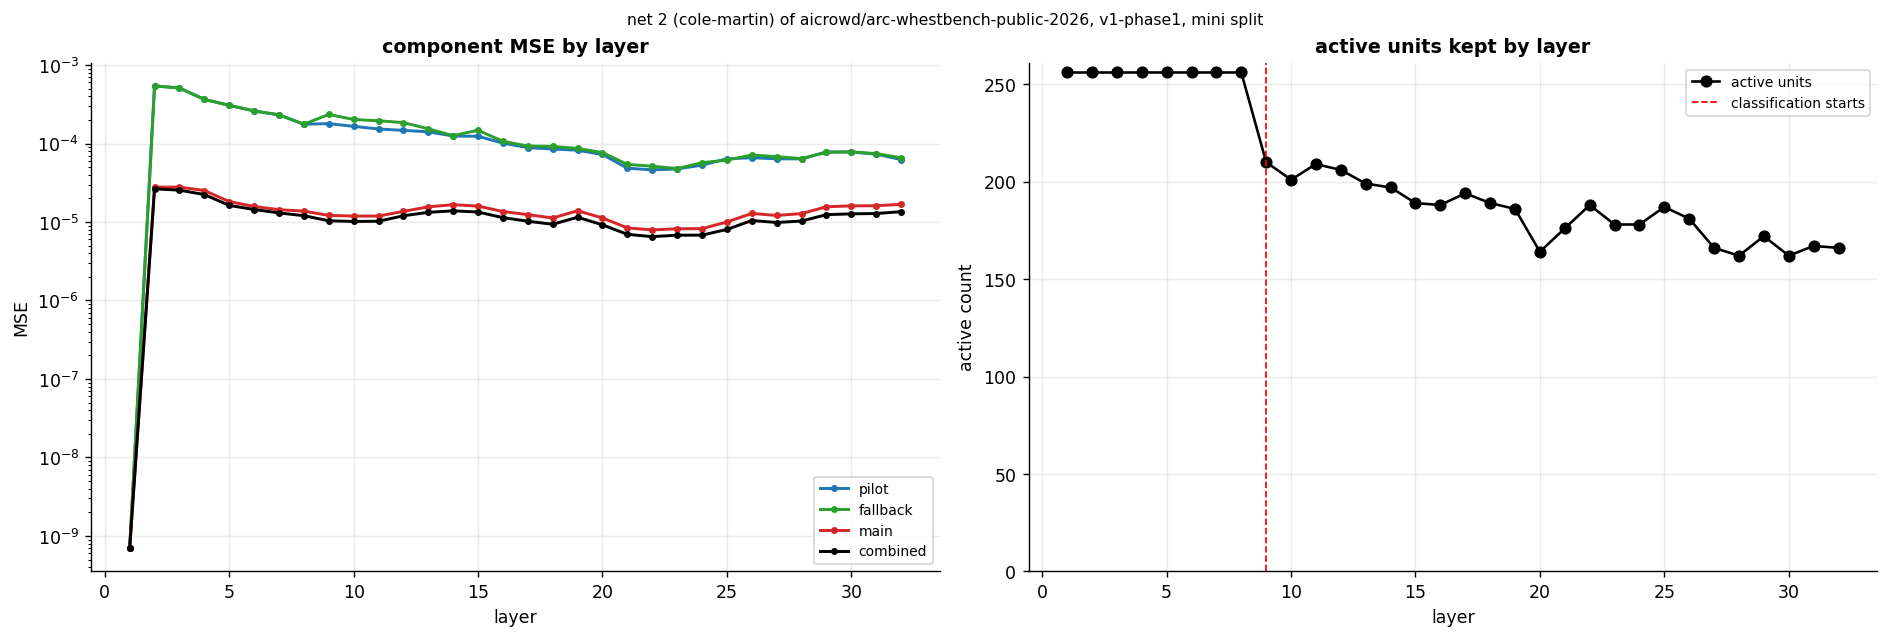

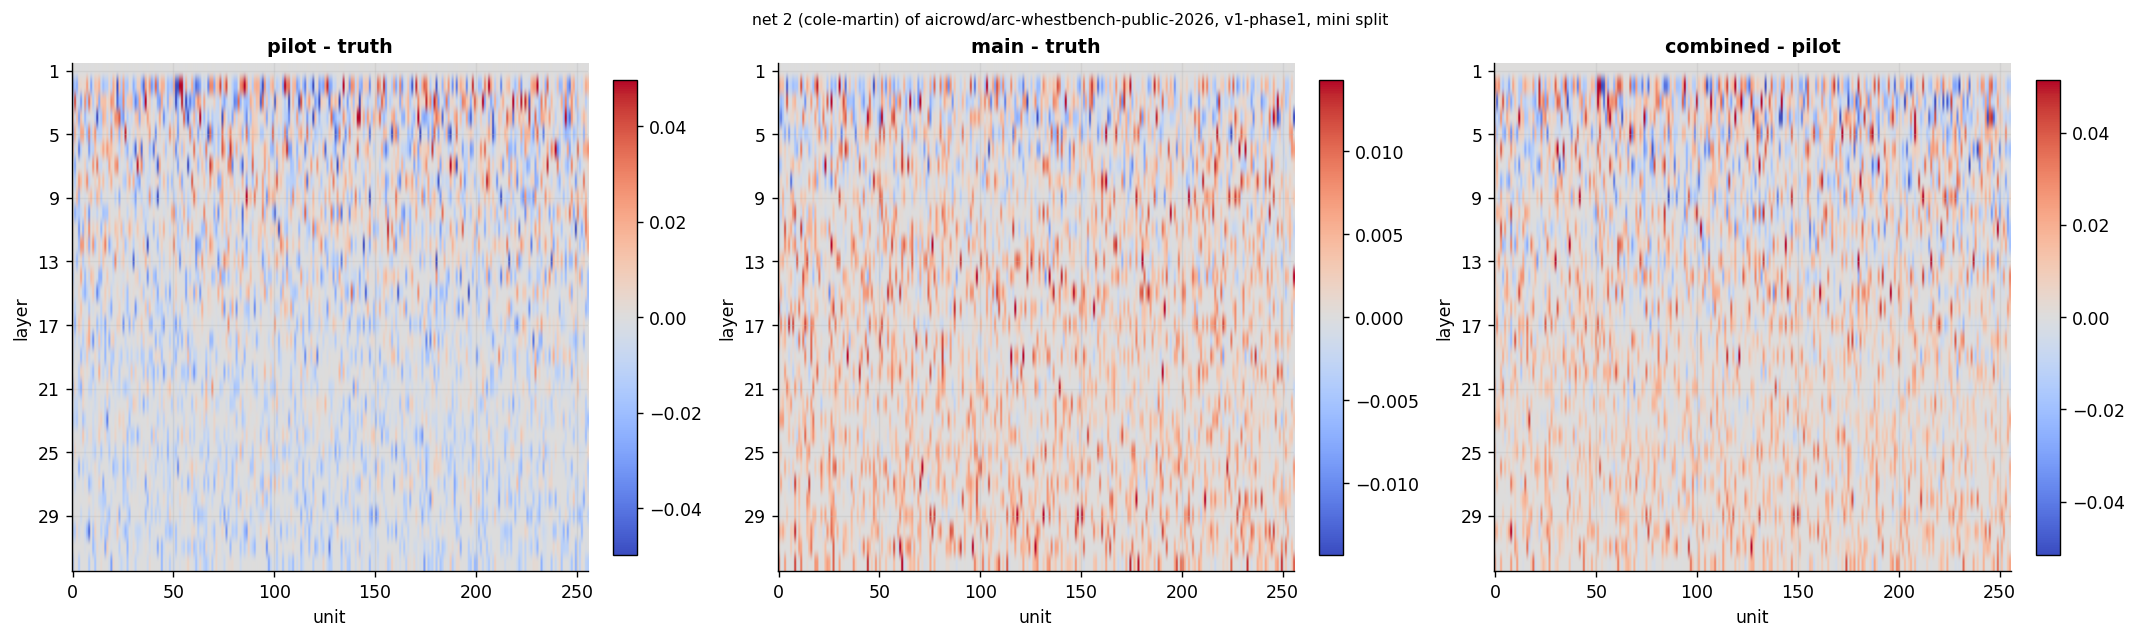

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)

for name, color in zip(component_names, ["#1f77b4", "#2ca02c", "#d62728", "black"]):
    axes[0].plot(layers, component_mse[name], "o-", ms=3, lw=1.7, label=name, color=color)
axes[0].set_yscale("log")
axes[0].set(title="component MSE by layer", xlabel="layer", ylabel="MSE")
axes[0].legend()

axes[1].plot(layers, components["active_counts"], "o-", color="black", label="active units")
axes[1].axvline(estimator_module._BLOCK_CLASS_START_LAYER, color="red", ls="--", lw=1, label="classification starts")
axes[1].set(title="active units kept by layer", xlabel="layer", ylabel="active count", ylim=(0, truth_one.shape[1] + 5))
axes[1].legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)

pilot_minus_truth = components["pilot"] - truth_one
main_minus_truth = components["main"] - truth_one
combined_minus_pilot = components["combined"] - components["pilot"]
for ax, data, title in [
    (axes[0], pilot_minus_truth, "pilot - truth"),
    (axes[1], main_minus_truth, "main - truth"),
    (axes[2], combined_minus_pilot, "combined - pilot"),
]:
    lim = np.quantile(np.abs(data), 0.995)
    im = ax.imshow(data, aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
    ax.set(title=title, xlabel="unit", ylabel="layer")
    ax.set_yticks(np.arange(0, truth_one.shape[0], 4), labels=np.arange(1, truth_one.shape[0] + 1, 4))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

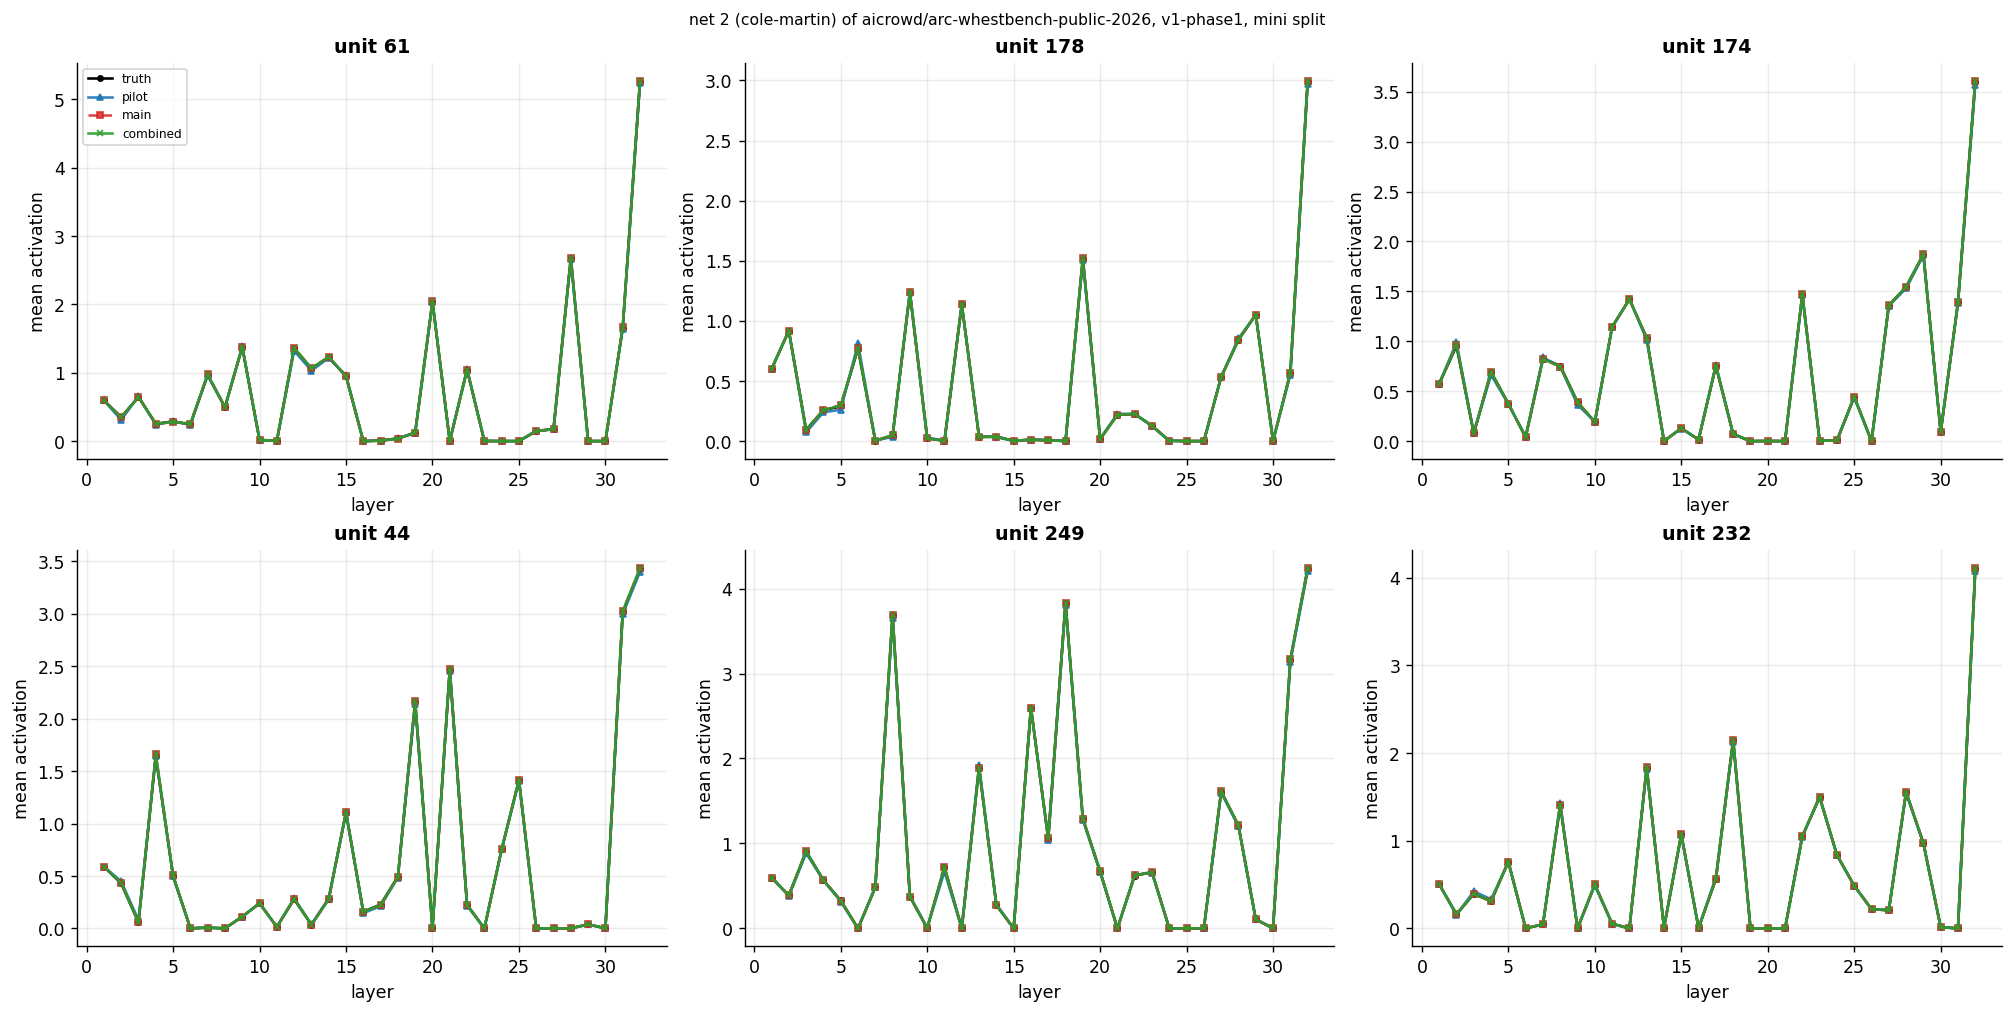

worst-unit final errors by component
unit  truth       pilot_err   main_err    combined_err
  61  5.2536e+00  -1.7474e-02  +1.5564e-02   +1.4243e-02
 178  2.9835e+00  -1.1770e-02  +1.3736e-02   +1.2716e-02
 174  3.5970e+00  -2.9569e-02  +1.3445e-02   +1.1724e-02
  44  3.4225e+00  -2.1684e-02  +1.3048e-02   +1.1659e-02
 249  4.2284e+00  -2.3721e-02  +1.3100e-02   +1.1627e-02
 232  4.0976e+00  -2.4402e-02  +1.2899e-02   +1.1407e-02


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
fig.suptitle(DIAG_NET_LABEL, fontsize=9)
for ax, unit_idx in zip(axes.ravel(), worst_units):
    ax.plot(layers, truth_one[:, unit_idx], "o-", color="black", ms=3, label="truth")
    ax.plot(layers, components["pilot"][:, unit_idx], "^-", color="#1f77b4", ms=3, alpha=0.9, label="pilot")
    ax.plot(layers, components["main"][:, unit_idx], "s--", color="#d62728", ms=3, alpha=0.85, label="main")
    ax.plot(layers, components["combined"][:, unit_idx], "x-", color="#2ca02c", ms=4, alpha=0.9, label="combined")
    ax.set(
        title=f"unit {unit_idx}",
        xlabel="layer",
        ylabel="mean activation",
    )
axes[0, 0].legend(fontsize=7)
plt.show()

print("worst-unit final errors by component")
print("unit  truth       pilot_err   main_err    combined_err")
for unit_idx in worst_units:
    print(
        f"{unit_idx:>4}  "
        f"{truth_one[-1, unit_idx]:>10.4e}  "
        f"{components['pilot'][-1, unit_idx] - truth_one[-1, unit_idx]:>+10.4e}  "
        f"{components['main'][-1, unit_idx] - truth_one[-1, unit_idx]:>+10.4e}  "
        f"{components['combined'][-1, unit_idx] - truth_one[-1, unit_idx]:>+12.4e}"
    )